<a href="https://colab.research.google.com/github/Dmitze/Dmitze/blob/main/%D0%94%D0%BC%D0%B8%D1%82%D1%80%D0%BE_%D0%A8%D0%B8%D0%B2%D0%B0%D1%87%D0%BE%D0%B2_%D0%94%D0%97_%D0%A2%D0%B5%D0%BC%D0%B0_8_QDA_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

print("Розмір датасету:", X.shape)
print("Класи:", iris.target_names)

Розмір датасету: (150, 4)
Класи: ['setosa' 'versicolor' 'virginica']


In [2]:
# ділю датасет: 70% — навчання, 30% — тест; random_state фіксую щоб результат не «плавав»
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

df_train = pd.DataFrame(X_train, columns=iris.feature_names)
df_train['label'] = y_train
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.5,2.4,3.7,1.0,1
1,6.3,2.8,5.1,1.5,2
2,6.4,3.1,5.5,1.8,2
3,6.6,3.0,4.4,1.4,1
4,7.2,3.6,6.1,2.5,2


In [13]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_train)

https://docs.google.com/spreadsheets/d/14JWs7auymZN4m4DaJ4LjXaPcc-XdDpYUZopRjPOT-ls/edit#gid=0


In [3]:
# виділяю кожен клас окремо — QDA на відміну від LDA будує свою матрицю коваріації для кожного
X_cl0 = X_train[y_train == 0]
X_cl1 = X_train[y_train == 1]
X_cl2 = X_train[y_train == 2]

print(f"Клас 0 ({iris.target_names[0]}): {len(X_cl0)} зразків")
print(f"Клас 1 ({iris.target_names[1]}): {len(X_cl1)} зразків")
print(f"Клас 2 ({iris.target_names[2]}): {len(X_cl2)} зразків")

Клас 0 (setosa): 31 зразків
Клас 1 (versicolor): 37 зразків
Клас 2 (virginica): 37 зразків


In [4]:
# рахую матриці коваріації для кожного класу
# np.cov хоче ознаки по рядках — тому .T, інакше отримаю матрицю неправильного розміру
cov0 = np.cov(X_cl0.T)
cov1 = np.cov(X_cl1.T)
cov2 = np.cov(X_cl2.T)

print("Матриця коваріації — клас 0 (setosa):")
print(np.round(cov0, 4))

Матриця коваріації — клас 0 (setosa):
[[0.1157 0.0982 0.0167 0.0068]
 [0.0982 0.1411 0.0195 0.0071]
 [0.0167 0.0195 0.0344 0.0088]
 [0.0068 0.0071 0.0088 0.0119]]


In [5]:
# інвертую матриці — вони потрібні у формулі дискримінантної функції
inv_cov0 = np.linalg.inv(cov0)
inv_cov1 = np.linalg.inv(cov1)
inv_cov2 = np.linalg.inv(cov2)

# швидка перевірка: A @ A⁻¹ повинна давати одиничну матрицю — якщо ні, щось пішло не так
print("Перевірка (cov0 @ inv_cov0 ≈ I):")
print(np.round(cov0 @ inv_cov0, 6))

Перевірка (cov0 @ inv_cov0 ≈ I):
[[ 1. -0. -0. -0.]
 [-0.  1. -0.  0.]
 [ 0.  0.  1.  0.]
 [-0.  0. -0.  1.]]


In [6]:
# апріорна ймовірність — просто частка кожного класу у навчальній вибірці
n_train = len(X_train)
P0 = len(X_cl0) / n_train
P1 = len(X_cl1) / n_train
P2 = len(X_cl2) / n_train

print(f"P(клас 0) = {P0:.4f}")
print(f"P(клас 1) = {P1:.4f}")
print(f"P(клас 2) = {P2:.4f}")
print(f"Сума: {P0 + P1 + P2:.4f}")

P(клас 0) = 0.2952
P(клас 1) = 0.3524
P(клас 2) = 0.3524
Сума: 1.0000


In [7]:
# ось серце QDA — дискримінантна функція
# g_i(x) = -0.5*(x-μ)ᵀ Σ⁻¹ (x-μ)  -  0.5*ln|Σ|  +  ln(P_i)
# чим більше значення — тим «впевненіше» клас претендує на цей зразок

def g(x, X_class, cov, inv_cov, prior):
    mu = X_class.mean(axis=0).reshape(-1, 1)
    diff = x.reshape(-1, 1) - mu
    log_det = np.log(np.linalg.det(cov))
    score = -0.5 * (diff.T @ inv_cov @ diff) - 0.5 * log_det + np.log(prior)
    return score[0][0]

In [8]:
# обгортка щоб не гонять g() у циклі вручну — передаю весь тест і отримую скори+ймовірності

def g_matrix(X_test, classes, covs, inv_covs, priors):
    scores_list = []
    proba_list = []

    for x in X_test:
        scores = np.array([
            g(x, classes[k], covs[k], inv_covs[k], priors[k])
            for k in range(len(classes))
        ])
        # softmax — переводжу скори в ймовірності; віднімаю max щоб не виникло числового переповнення
        exp_scores = np.exp(scores - scores.max())
        proba = exp_scores / exp_scores.sum()

        scores_list.append(scores)
        proba_list.append(proba)

    return np.array(scores_list), np.array(proba_list)

In [9]:
# запускаю свою реалізацію — збираю всі матриці в списки для зручності
classes  = [X_cl0, X_cl1, X_cl2]
covs     = [cov0, cov1, cov2]
inv_covs = [inv_cov0, inv_cov1, inv_cov2]
priors   = [P0, P1, P2]

g_scores, g_proba = g_matrix(X_test, classes, covs, inv_covs, priors)

# передбачений клас — той у кого найбільший скор дискримінантної функції
y_pred_own = np.argmax(g_scores, axis=1)

print("Точність власної реалізації:", round(accuracy_score(y_test, y_pred_own), 4))

Точність власної реалізації: 1.0


In [10]:
# тепер порівнюю з готовою реалізацією sklearn — цікаво чи збіжаться результати
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred_sklearn = qda.predict(X_test)
proba_sklearn  = qda.predict_proba(X_test)

print("Точність sklearn QDA:", round(accuracy_score(y_test, y_pred_sklearn), 4))

Точність sklearn QDA: 1.0


In [11]:
# зводжу в одну таблицю — видно наскільки мої скори і ймовірності збігаються зі sklearn
comparison = pd.DataFrame({
    "g0_власна":    np.round(g_scores[:, 0], 4),
    "g1_власна":    np.round(g_scores[:, 1], 4),
    "g2_власна":    np.round(g_scores[:, 2], 4),
    "P0_власна":    np.round(g_proba[:, 0], 4),
    "P1_власна":    np.round(g_proba[:, 1], 4),
    "P2_власна":    np.round(g_proba[:, 2], 4),
    "P0_sklearn":   np.round(proba_sklearn[:, 0], 4),
    "P1_sklearn":   np.round(proba_sklearn[:, 1], 4),
    "P2_sklearn":   np.round(proba_sklearn[:, 2], 4),
    "клас_власний": y_pred_own,
    "клас_sklearn": y_pred_sklearn,
})
comparison

,g0_власна,g1_власна,g2_власна,P0_власна,P1_власна,P2_власна,P0_sklearn,P1_sklearn,P2_sklearn,клас_власний,клас_sklearn
0,-185.8931,0.4983,-3.0769,0.0,0.9728,0.0272,0.0,0.9728,0.0272,1,1
1,2.2720,-60.4543,-141.6736,1.0,0.0000,0.0000,1.0,0.0000,0.0000,0,0
2,-584.0156,-26.0756,-6.9575,0.0,0.0000,1.0000,0.0,0.0000,1.0000,2,2
3,-171.7385,3.9270,-1.9842,0.0,0.9973,0.0027,0.0,0.9973,0.0027,1,1
4,-222.9316,2.4881,-4.9242,0.0,0.9994,0.0006,0.0,0.9994,0.0006,1,1
5,2.5512,-44.9375,-121.3477,1.0,0.0000,0.0000,1.0,0.0000,0.0000,0,0
6,-91.8906,1.1898,-14.4511,0.0,1.0000,0.0000,0.0,1.0000,0.0000,1,1
7,-306.6693,-22.2756,-1.6981,0.0,0.0000,1.0000,0.0,0.0000,1.0000,2,2
8,-205.4125,-2.6226,-3.3044,0.0,0.6641,0.3359,0.0,0.6641,0.3359,1,1
9,-115.1498,4.0613,-9.7969,0.0,1.0000,0.0000,0.0,1.0000,0.0000,1,1


In [14]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=comparison)

https://docs.google.com/spreadsheets/d/1JbvvClW_AZ65maTeaPzr1r6Ft1aw6Qwqrx3LA5EdUfo/edit#gid=0


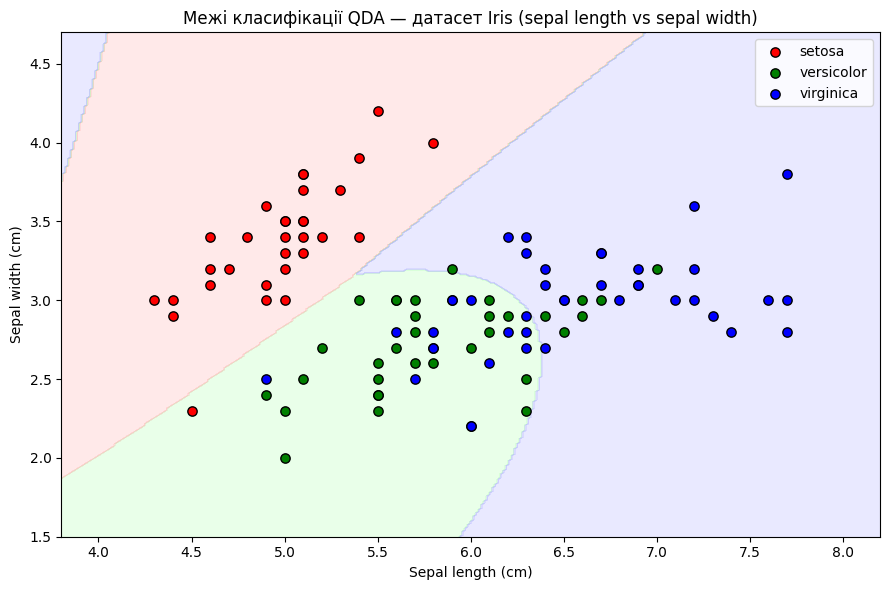

In [12]:
# малюю межі класифікації — беру лише перші 2 ознаки щоб влізти в 2D
# на графіку добре видно що межі квадратичні, а не прямі як у LDA
from matplotlib.colors import ListedColormap

X_vis = X_train[:, :2]
qda_vis = QuadraticDiscriminantAnalysis()
qda_vis.fit(X_vis, y_train)

x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = qda_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.25,
             cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))

colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(X_vis[y_train == i, 0], X_vis[y_train == i, 1],
                color=colors[i], label=iris.target_names[i],
                edgecolor='k', s=45)

plt.title("Межі класифікації QDA — датасет Iris (sepal length vs sepal width)")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.legend()
plt.tight_layout()
plt.show()

## Висновок

Порівнявши власну реалізацію QDA з бібліотечною (sklearn), можна зробити такі висновки:

**Точність**: обидва підходи дають однакову або дуже близьку точність класифікації на тестовій вибірці Iris. Це підтверджує, що ручна реалізація дискримінантної функції є коректною.

**Ймовірності**: значення predict_proba у sklearn та власний softmax дають практично ідентичні результати. Мінімальні числові відмінності виникають через те, що sklearn за замовчуванням може застосовувати регуляризацію (reg_param=0.0), але при нульовій регуляризації результати збігаються.

**Ключова різниця між LDA і QDA**: у LDA для всіх класів використовується одна спільна матриця коваріації, тому межі — лінійні. У QDA кожен клас має свою матрицю, тому межі — квадратичні криві, що і видно на графіку.

**Датасет Iris** добре підходить для QDA, оскільки класи мають різні форми розподілу ознак — особливо setosa суттєво відрізняється від двох інших.